In [4]:
## observation 


import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.stats import norm
from scipy.stats import multivariate_normal
import seaborn as sns
from scipy.stats import gaussian_kde

mwr_coeff = "../mwr_polar_coefficients.csv"
df = pd.read_csv(mwr_coeff, header=None, names=["channel", "c0", "c1", "c2"])
obsTB = df["c0"].values
obsLD=[13.2, 10.0, 6.9, 5.9, 4.5, 1.4]  

print("obsTB:", obsTB)
print("obsLD:", obsLD)

obsTB: [908.46972469 479.08699872 338.75165919 251.70653583 192.47340754
 141.07444985]
obsLD: [13.2, 10.0, 6.9, 5.9, 4.5, 1.4]


In [5]:
## model grids

with h5py.File("/home/jihenghu/JHCanoe/build_euler_apative_bg/bin/model_LUT_TB_LD.h5","r") as f:
    TBs=f["TBs"][1:7,1:6,:]
    LDs=f["LDs"][1:7,1:6,:]

xNH3s= [300,325,350,375,400,425,450,475][1:7]
Thetas  = [160,165,170,175,180,185,190,195][1:6]

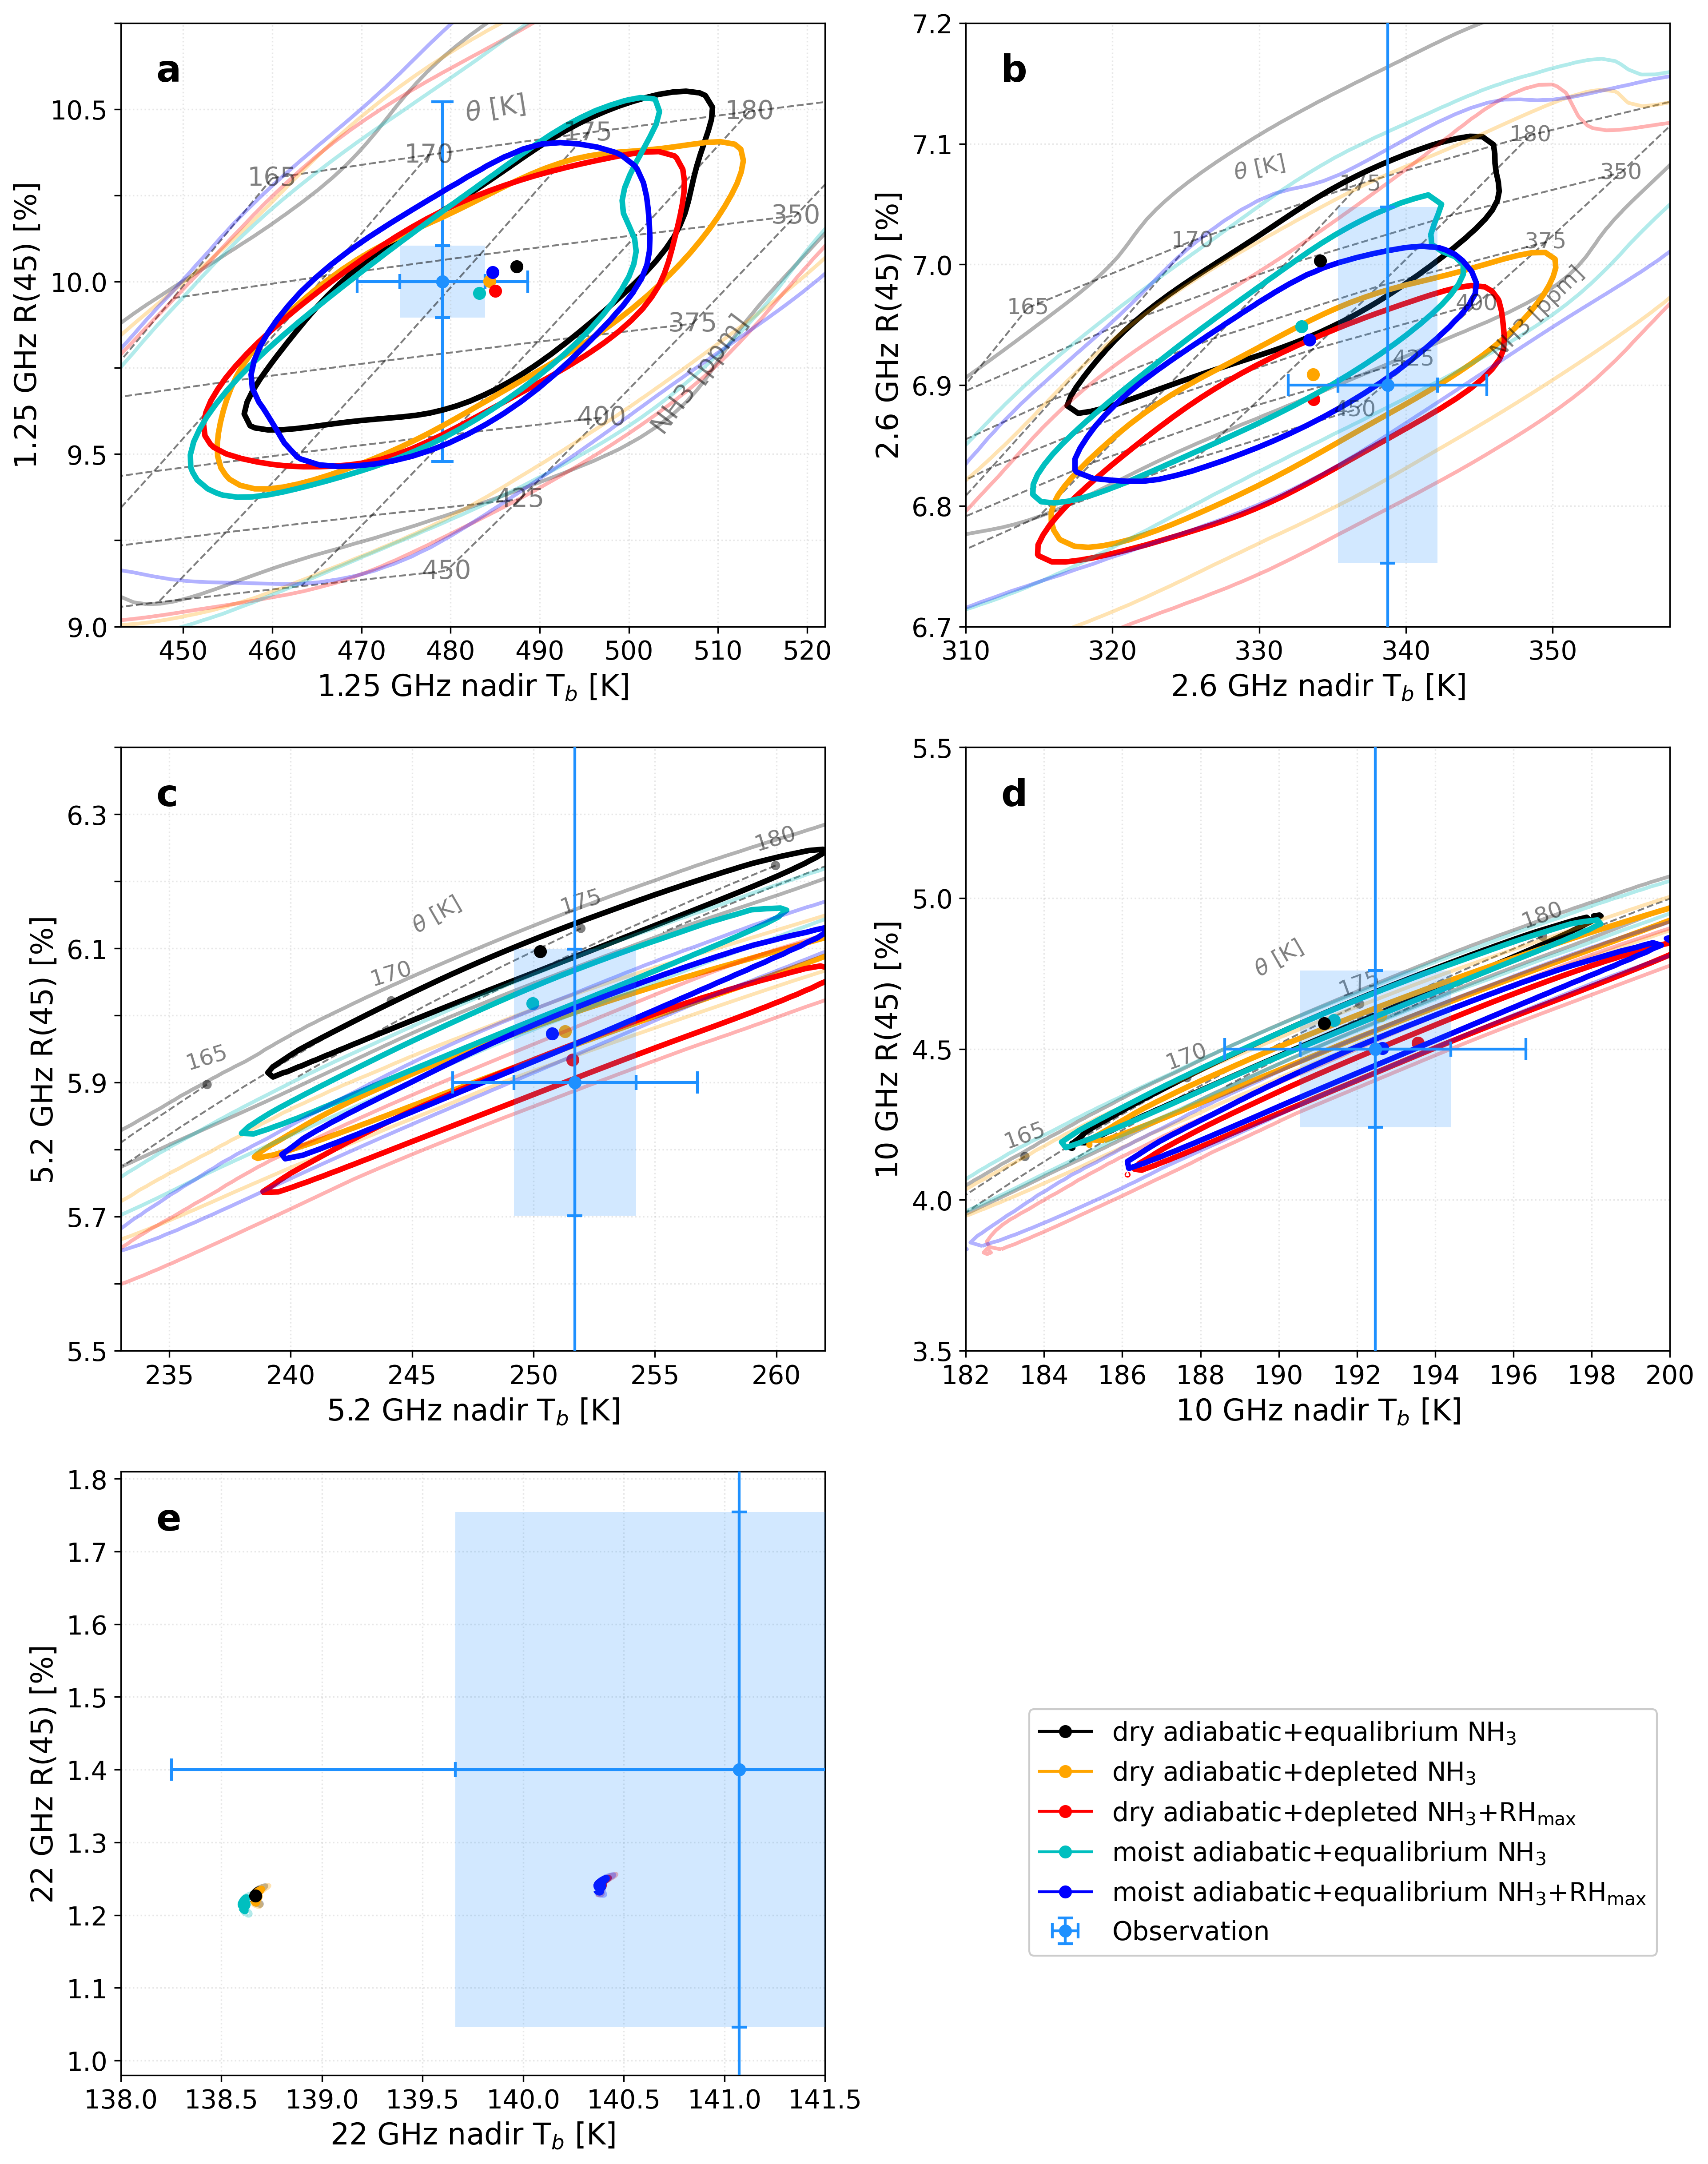

In [11]:
# plot

fig,axs= plt.subplots(3,2,figsize=(15,20), dpi=300)
axes=axs.flatten()




ax0=axes[0]
for ix, xnh3 in enumerate(xNH3s):
    ax0.plot(TBs[ix,:,1], LDs[ix,:,1],"k--",alpha=0.5, linewidth=1)
    if ix>0:
        ax0.text(TBs[ix, -1,1], LDs[ix, -1,1], f"{xnh3}", fontsize=14, alpha=0.5, va="center",ha="center")

for it, theta in enumerate(Thetas):
    ax0.plot(TBs[:,it,1], LDs[:,it,1],"k--",alpha=0.5, linewidth=1)
    if it<len(xNH3s)-2:
        ax0.text(TBs[0,it,1], LDs[0,it,1], f"{theta:02d}", fontsize=14, alpha=0.5, va="center",ha="center")

ax0.text(508,9.73, "NH3 [ppm]", color="k", alpha=0.5, fontsize=14, rotation=53,va="center",ha="center")
ax0.text(485,10.5,r"$\theta$ [K]", color="k", alpha=0.5, fontsize=14, rotation=9,va="center",ha="center")


## observations

ax0.errorbar(obsTB[1],obsLD[1], xerr=0.01*obsTB[1], yerr=0.5/obsTB[1]*100., fmt='o', linewidth=1.5,capsize=4, capthick=1.5, label="Observation", color='dodgerblue')
ax0.errorbar(obsTB[1],obsLD[1], xerr=0.02*obsTB[1], yerr=2.5/obsTB[1]*100., fmt='o', linestyle='--', linewidth=1.5,capsize=6,capthick=1.5, color='dodgerblue')

ax0.fill_between([obsTB[1]-0.01*obsTB[1],obsTB[1]+0.01*obsTB[1]], obsLD[1]+0.5/obsTB[1]*100., obsLD[1]-0.5/obsTB[1]*100., alpha=0.2, linewidth=0, color="dodgerblue")


# ## best fit and EZ reference
# ax0.errorbar(fitTB[1], fitLD[1], xerr=fitTB_std[1], yerr=fitLD_std[1], fmt='o', linewidth=1.5,capsize=4,capthick=1.5, color='k', label="NP best-fit", zorder=9)

# ax0.errorbar(ezTB[1], ezLD[1], xerr=ezTB_std[1], yerr=ezLD_std[1], fmt='o', linewidth=1.5,capsize=4,capthick=1.5, color='crimson', zorder=9)

GHz=1.25

ax0.set_xlabel(fr'{GHz} GHz nadir T$_b$ [K]', fontsize=14)
ax0.set_ylabel(fr'{GHz} GHz R(45) [%]', fontsize=14)
# ax.set_title(f'Channel {ich+1}')

ax0.tick_params(axis='x', labelsize=14)  # Change 14 to any desired font size
ax0.tick_params(axis='y', labelsize=14)  # Change 14 to any desired font size

ax0.set_xlim(443,522)
ax0.set_ylim(9.25,10.75)
ax0.set_yticks([9.0,9.25,9.5,9.75,10.0,10.25,10.5, 10.75])
ax0.set_yticklabels([9.0,'',9.5,'',10.0,'',10.5,''])




# axes[0].text(880,12.55, "NH3 [ppm]", color="k",  alpha=0.5,fontsize=12,rotation=-25,va="center",ha="center")
# axes[0].text(888,13.5,r"$\theta$ [K]", color="k", alpha=0.5,fontsize=12,rotation=-45,va="center",ha="center")

axes[2-1].text(349,6.96, "NH3 [ppm]", color="k",  alpha=0.5,fontsize=12,rotation=45,va="center",ha="center")
axes[2-1].text(330,7.08,r"$\theta$ [K]", color="k", alpha=0.5,fontsize=12,rotation=12,va="center",ha="center")

# axes[3].text(349,6.95, "NH3 [ppm]", color="k",  alpha=0.5,fontsize=12,rotation=45,va="center",ha="center")
axes[3-1].text(246,6.15,r"$\theta$ [K]", color="k", alpha=0.5,fontsize=12,rotation=30,va="center",ha="center")
axes[4-1].text(190,4.8,r"$\theta$ [K]", color="k", alpha=0.5,fontsize=12,rotation=30,va="center",ha="center")
              

for ig in [2,]:
    for ix, xnh3 in enumerate(xNH3s):
        axes[ig-1].plot(TBs[ix,:,ig], LDs[ix,:,ig],"k--",alpha=0.5, linewidth=1)
        if ig == 0:
            axes[0].text(TBs[ix, -1,ig]-2, LDs[ix, -1,ig]-0.08, f"{xnh3}", fontsize=12,  alpha=0.5,rotation=-25, va="center",ha="center")

        if ig == 2:
            if xnh3==325: continue
            axes[1].text(TBs[ix, -1,ig], LDs[ix, -1,ig], f"{xnh3}", fontsize=12, alpha=0.5,va="center",ha="center")

    for it, theta in enumerate(Thetas):
        axes[ig-1].plot(TBs[::,it,ig], LDs[::,it,ig],"k--",alpha=0.5, linewidth=1)
        if ig ==0:
            axes[ig-1].text(TBs[0,it,ig], LDs[0,it,ig]+0.06, f"{theta:02d}", fontsize=12,  alpha=0.5, rotation=-47,va="center",ha="center")
        if ig==2:
            if theta==185: continue
            axes[ig-1].text(TBs[0,it,ig], LDs[0,it,ig], f"{theta:02d}", fontsize=12, alpha=0.5, va="center",ha="center")

for ig in [3,4]:
    ix=0
    # axes[ig].plot(TBs[ix,:,ig], LDs[ix,:,ig],"k--",alpha=0.5, linewidth=1)
    # axes[ig].plot(TBs[-1,:,ig], LDs[-1,:,ig],"k--",alpha=0.5, linewidth=1)

    for it, theta in enumerate(Thetas):
        

        # if it==0: continue
        axes[ig-1].scatter(TBs[ix,it,ig], LDs[ix,it,ig],marker=".", s=100, color="k", alpha=0.5, edgecolor='none')
        if ig==4: 
            axes[ig-1].plot(TBs[::,it,ig], LDs[::,it,ig],"k--",alpha=0.5, linewidth=1)
            if it==4: continue
            axes[ig-1].text(TBs[ix,it,ig], LDs[ix,it,ig]+0.07, f"{theta:02d}", fontsize=12, alpha=0.5, rotation=20,va="center",ha="center") 
        else: 
            
            axes[ig-1].plot(TBs[:-1,it,ig], LDs[:-1,it,ig],"k--",alpha=0.5, linewidth=1)
            if it==4: continue
            axes[ig-1].text(TBs[ix,it,ig], LDs[ix,it,ig]+0.04, f"{theta:02d}", fontsize=12, alpha=0.5,rotation=17, va="center",ha="center")


for ix, xnh3 in enumerate(xNH3s):
    axes[3].plot(TBs[ix,:,5], LDs[ix,:,5],"k--",alpha=0.5, linewidth=1, zorder=11)

for it, theta in enumerate(Thetas):
    axes[3].plot(TBs[::,it,5], LDs[::,it,5],"k--",alpha=0.5, linewidth=1, zorder=11)


for ig in [2,3,4,5]:

    axes[ig-1].errorbar(obsTB[ig],obsLD[ig], xerr=0.01*obsTB[ig], yerr=0.5/obsTB[ig]*100., fmt='o', linewidth=1.5,capsize=4, capthick=1.5, label="North Pole", color='dodgerblue', zorder=5)

    axes[ig-1].errorbar(obsTB[ig],obsLD[ig], xerr=0.02*obsTB[ig], yerr=2.5/obsTB[ig]*100., fmt='o', linestyle='--',linewidth=1.5,capsize=6,capthick=1.5,color='dodgerblue', zorder=5)

    axes[ig-1].fill_between([obsTB[ig]-0.01*obsTB[ig],obsTB[ig]+0.01*obsTB[ig]], obsLD[ig]+0.5/obsTB[ig]*100., obsLD[ig]-0.5/obsTB[ig]*100., alpha=0.2, linewidth=0, color="dodgerblue", zorder=5)

    axes[ig-1].tick_params(axis='x', labelsize=14)  # Change 14 to any desired font size
    axes[ig-1].tick_params(axis='y', labelsize=14)  # Change 14 to any desired font size
    GHz=["0.6","1.25","2.6","5.2","10","22"][ig]
    axes[ig-1].set_xlabel(fr'{GHz} GHz nadir T$_b$ [K]', fontsize=14)
    axes[ig-1].set_ylabel(fr'{GHz} GHz R(45) [%]', fontsize=14)

    # # axes[ig].scatter(ezTb[ig][0], (ezTb[ig][0]- ezTb[ig][3])/ ezTb[ig][0] *100.,color="r",marker="^",s=150, label="Equatorial Zone reference")
    # axes[ig].errorbar(ezTB[ig], ezLD[ig], xerr=ezTB_std[ig], yerr=ezLD_std[ig], fmt='o', linewidth=1.5,capsize=4,capthick=1.5, color='crimson', label="Equatorial Zone", zorder=9)

    # # axes[ig].scatter(fittb[ig][0], (fittb[ig][0]- fittb[ig][3])/ fittb[ig][0] *100.,linewidths=1,color="gold", edgecolor='k', marker="^",s=120, label="NP best-fit", zorder=10)
    # axes[ig].errorbar(fitTB[ig], fitLD[ig], xerr=fitTB_std[ig], yerr=fitLD_std[ig], fmt='o', linewidth=1.5,capsize=4,capthick=1.5, color='k', label="Adiabatic fit", zorder=9)




# axes[0-1].plot([],[],"k--",alpha=1, linewidth=1, label="Forward modelings", zorder=1)

# index=[1,2,3,0]
# handles, labels = axes[0].get_legend_handles_labels()
# axes[0].legend([handles[i] for i in index], [labels[i] for i in index], fontsize=14)

# # axes[0].legend(loc="lower right", fontsize=14)
# axes[0-1].set_yticks([12,12.5,13,13.5,14,14.5, 15])
# axes[0-1].set_yticklabels([12,'',13,'',14,'', 15])

# axes[0-1].set_xticks([800,825,850,875, 900,925,950])
# axes[0-1].set_xticklabels([800,"",850,"",900,"",950])

# axes[2].set_yticks([6.2,6.6,7.0,7.4,7.8])
# axes[3].set_yticks([5,5.5,6,6.5,7])
axes[4-1].set_yticks([3,3.5,4,4.5,5,5.5,6])

# axes[0-1].set_xlim(800,950)
# axes[0-1].set_ylim(12,15)

axes[2-1].set_ylim(6.7,7.2)
axes[2-1].set_xlim(310,358)

axes[3-1].set_xlim(233,262)
axes[3-1].set_ylim(5.5,6.4)
axes[3-1].set_yticks([5.5,5.6,5.7,5.8,5.9,6.0,6.1,6.2,6.3,6.4])
axes[3-1].set_yticklabels([5.5,'',5.7,'',5.9,'',6.1,'',6.3,''])

axes[4-1].set_xlim(182,200)
axes[4-1].set_ylim(3.5,5.5)
# axes[4].set_yticks([5,5.5,6,6.5,7])
# 
axes[5-1].set_xlim(138,141.5)
# axes[5-1].set_xlim(137.5,143)
axes[5-1].set_ylim(0.98,1.81)
# axes[5-1].set_ylim(0.5,2)
# axes[5-1].set_yticks([0.6,0.8,1.0,1.2,1.4,1.6,1.8,2.0])
# axes[5-1].set_yticklabels([0.6,'',1.0,'',1.4,'',1.8,''])

for ax in axes:
    ax.grid(True, linestyle=':', alpha=0.3)

    # ticklabels fontsize
    ax.tick_params(axis='x', labelsize=14)  
    ax.tick_params(axis='y', labelsize=14)  
    # Show both x and y axes label fontsize
    ax.xaxis.label.set_size(16)
    ax.yaxis.label.set_size(16)

for ig in range(5):
    axes[ig].text(0.05, 0.95, ['a','b','c','d','e','f'][ig], transform=axes[ig].transAxes, fontsize=20, fontweight='bold', va='top', ha='left')
# plt.tight_layout()


for ix in range(0,5):
    ax = axes[ix]
    ich=ix+1

    h5file=h5py.File('monte_carlo_dry_uniform_1000.h5', 'r') ## dry+gradient
    y=    h5file['R45_samples'][:,ich]
    x=    h5file['BT_samples'][:,ich]
    x_grid = np.linspace(x.min(), x.max(), 100)
    y_grid = np.linspace(y.min(), y.max(), 100)
    X, Y = np.meshgrid(x_grid, y_grid)
    kde = gaussian_kde([x, y])
    mean = [np.mean(x), np.mean(y)]
    cov = np.cov(x, y)

    levels = [ multivariate_normal.pdf(mean, mean=mean, cov=cov) * 0.6065306597,  # ~1 std dev
            multivariate_normal.pdf(mean, mean=mean, cov=cov) * 0.1353352832,  # ~2 std dev
            #   multivariate_normal.pdf(mean, mean=mean, cov=cov) * 0.01110899654, # ~3 std dev
            ] 
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    CS = ax.contour(X, Y,Z, levels=[levels[0],],  colors=('k',), linewidths=3, alpha=1)
    CS = ax.contour(X, Y,Z, levels=[levels[1],],  colors=('k',), linewidths=2, alpha=0.3)
    ax.plot(np.median(x),np.median(y),marker="o",color="k", label=r"dry adiabatic+equalibrium NH$_3$", zorder=10)





    h5file=h5py.File('monte_carlo_dry_gradient_1000.h5', 'r') ## dry+gradient
    y=    h5file['R45_samples'][:,ich]
    x=    h5file['BT_samples'][:,ich]
    x_grid = np.linspace(x.min(), x.max(), 100)
    y_grid = np.linspace(y.min(), y.max(), 100)
    X, Y = np.meshgrid(x_grid, y_grid)
    kde = gaussian_kde([x, y])
    mean = [np.mean(x), np.mean(y)]
    cov = np.cov(x, y)

    levels = [ multivariate_normal.pdf(mean, mean=mean, cov=cov) * 0.6065306597,  # ~1 std dev
            multivariate_normal.pdf(mean, mean=mean, cov=cov) * 0.1353352832,  # ~2 std dev
            #   multivariate_normal.pdf(mean, mean=mean, cov=cov) * 0.01110899654, # ~3 std dev
            ] 
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    CS = ax.contour(X, Y,Z, levels=[levels[0],],  colors=('orange',), linewidths=3, alpha=1)
    CS = ax.contour(X, Y,Z, levels=[levels[1],],  colors=('orange',), linewidths=2, alpha=0.3)
    ax.plot(np.median(x),np.median(y),marker="o",color="orange", label=r"dry adiabatic+depleted NH$_3$")



    h5file=h5py.File('monte_carlo_dry_gradient_rhmax_1000.h5', 'r') ## dry+gradient
    y=    h5file['R45_samples'][:,ich]
    x=    h5file['BT_samples'][:,ich]
    x_grid = np.linspace(x.min(), x.max(), 100)
    y_grid = np.linspace(y.min(), y.max(), 100)
    X, Y = np.meshgrid(x_grid, y_grid)
    kde = gaussian_kde([x, y])
    mean = [np.mean(x), np.mean(y)]
    cov = np.cov(x, y)

    levels = [ multivariate_normal.pdf(mean, mean=mean, cov=cov) * 0.6065306597,  # ~1 std dev
            multivariate_normal.pdf(mean, mean=mean, cov=cov) * 0.1353352832,  # ~2 std dev
            #   multivariate_normal.pdf(mean, mean=mean, cov=cov) * 0.01110899654, # ~3 std dev
            ] 
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    CS = ax.contour(X, Y,Z, levels=[levels[0],],  colors=('r',),linewidths=3, alpha=1)
    CS = ax.contour(X, Y,Z, levels=[levels[1],],  colors=('r',),linewidths=2, alpha=0.3)
    ax.plot(np.median(x),np.median(y),marker="o",color="r", label=r"dry adiabatic+depleted NH$_3$+RH$_\text{max}$")


    h5file= h5py.File('monte_carlo_moist_1000.h5', 'r')
    y=    h5file['R45_samples'][:,ich]
    x=    h5file['BT_samples'][:,ich]
    x_grid = np.linspace(x.min(), x.max(), 100)
    y_grid = np.linspace(y.min(), y.max(), 100)
    X, Y = np.meshgrid(x_grid, y_grid)
    kde = gaussian_kde([x, y])
    mean = [np.mean(x), np.mean(y)]
    cov = np.cov(x, y)

    levels = [ multivariate_normal.pdf(mean, mean=mean, cov=cov) * 0.6065306597,  # ~1 std dev
            multivariate_normal.pdf(mean, mean=mean, cov=cov) * 0.1353352832,  # ~2 std dev
            #   multivariate_normal.pdf(mean, mean=mean, cov=cov) * 0.01110899654, # ~3 std dev
            ] 
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    CS = ax.contour(X, Y,Z, levels=[levels[0],],  colors=('c',) ,linewidths=3, alpha=1)
    CS = ax.contour(X, Y,Z, levels=[levels[1],],  colors=('c',) ,linewidths=2, alpha=0.3)
    ax.plot(np.median(x),np.median(y),marker="o",color="c", label=r"moist adiabatic+equalibrium NH$_3$")


    h5file= h5py.File('monte_carlo_moist_rhmax_1000.h5', 'r')
    y=    h5file['R45_samples'][:,ich]
    x=    h5file['BT_samples'][:,ich]
    x_grid = np.linspace(x.min(), x.max(), 100)
    y_grid = np.linspace(y.min(), y.max(), 100)
    X, Y = np.meshgrid(x_grid, y_grid)
    kde = gaussian_kde([x, y])
    mean = [np.mean(x), np.mean(y)]
    cov = np.cov(x, y)

    levels = [ multivariate_normal.pdf(mean, mean=mean, cov=cov) * 0.6065306597,  # ~1 std dev
            multivariate_normal.pdf(mean, mean=mean, cov=cov) * 0.1353352832,  # ~2 std dev
            #   multivariate_normal.pdf(mean, mean=mean, cov=cov) * 0.01110899654, # ~3 std dev
            ] 
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    CS = ax.contour(X, Y,Z, levels=[levels[0],],  colors=('b',) ,linewidths=3, alpha=1)
    CS = ax.contour(X, Y,Z, levels=[levels[1],],  colors=('b',) ,linewidths=2, alpha=0.3)
    ax.plot(np.median(x),np.median(y),marker="o",color="b", label=r"moist adiabatic+equalibrium NH$_3$+RH$_\text{max}$")


# Add a global legend
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), fontsize=14, ncol=1, loc='lower right', framealpha=1, bbox_to_anchor=(0.9, 0.15))
# fig.legend(fontsize=24, ncol=1, loc='lower right', framealpha=1, bbox_to_anchor=(0.8, 0.3))
axes[5].axis('off') 

plt.savefig("Extend_LUT_dry_adb.pdf", transparent=True, bbox_inches='tight')
plt.show()